# Statistical Analysis of Apple Stock Returns and Volatility

## 1. Project Goal

In this project, we analyze Apple stock data in order to gain insights into the stock's price behavior over time.

More specifically, we investigate possible trends and patterns in the stock returns, as well as how the stock's volatility evolves over time.

## 2. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats

## 3. Data Collection

We use historical Apple stock data obtained from Yahoo Finance through the yfinance library.

In [2]:
apple = yf.download('AAPL', start='2020-01-01', end='2025-01-01', auto_adjust = False)
apple.columns = apple.columns.droplevel(1)

apple.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2020-01-02,72.333885,75.087502,75.150002,73.797501,74.059998,135480400
2020-01-03,71.630630,74.357498,75.144997,74.125000,74.287498,146322800
2020-01-06,72.201424,74.949997,74.989998,73.187500,73.447502,118387200
2020-01-07,71.861847,74.597504,75.224998,74.370003,74.959999,108872000
2020-01-08,73.017838,75.797501,76.110001,74.290001,74.290001,132079200


**Remark:** The dataset contains data about opening and closing prices, daily highs and lows, adjusted closing prices, and trading volume.

## 4. Data Inspection & Cleaning

Initially, we inspect the structure and quality of the dataset.

In [3]:
apple.shape

(1258, 6)

In [4]:
apple.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [5]:
apple.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  1258 non-null   float64
 1   Close      1258 non-null   float64
 2   High       1258 non-null   float64
 3   Low        1258 non-null   float64
 4   Open       1258 non-null   float64
 5   Volume     1258 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.8 KB


In [6]:
apple.isnull().sum()

Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

**Remark:** All columns are numerical and the dataset contains no missing values.

In [7]:
apple.describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.377787,154.108800,155.660348,152.379123,153.951948,9.057103e+07
std,41.851999,41.520877,41.654310,41.305929,41.466618,5.324438e+07
min,54.163696,56.092499,57.125000,53.152500,57.020000,2.323470e+07
25%,126.279123,129.624996,130.755005,127.505001,129.017506,5.546825e+07
50%,149.968628,152.805000,154.570000,150.825005,152.575005,7.628335e+07
75%,175.902016,178.850006,180.160000,177.115005,178.500004,1.077425e+08
max,257.375610,259.019989,260.100006,257.630005,258.190002,4.265100e+08


The descriptive statistics provide an initial overview of the stock’s main characteristics.

## 5. Exploratory Price Analysis

We begin our analysis by examining the evolution of Apple's stock price over time.

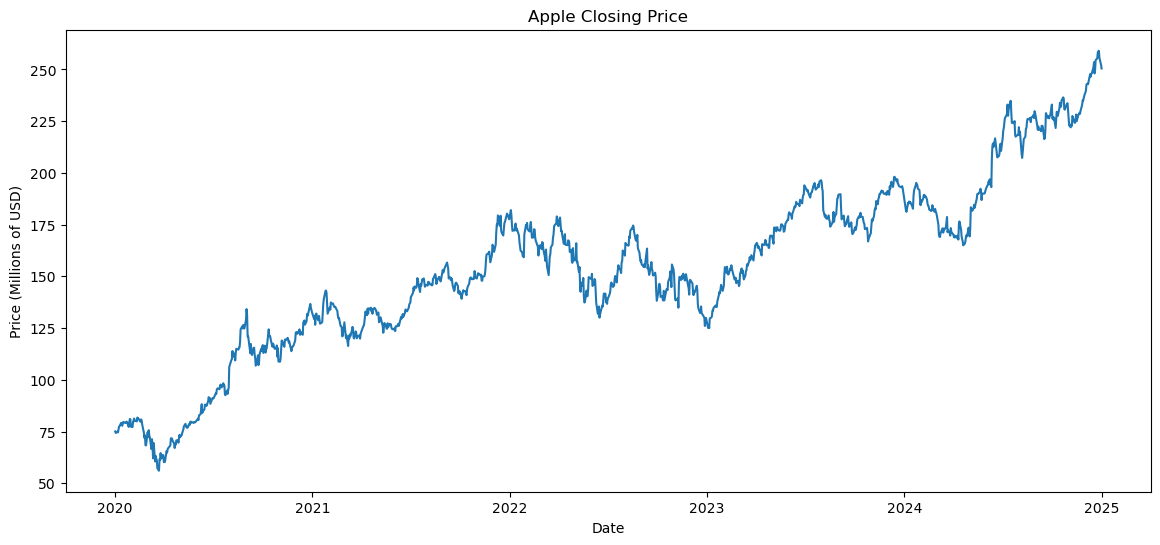

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(apple['Close'])
plt.title('Apple Closing Price')
plt.xlabel('Date')
plt.ylabel('Price (Millions of USD)')
plt.show()

**Remark:** The stock price exhibits a clear long-term upward trend, accompanied by periods of increased volatility and sharp market movements.

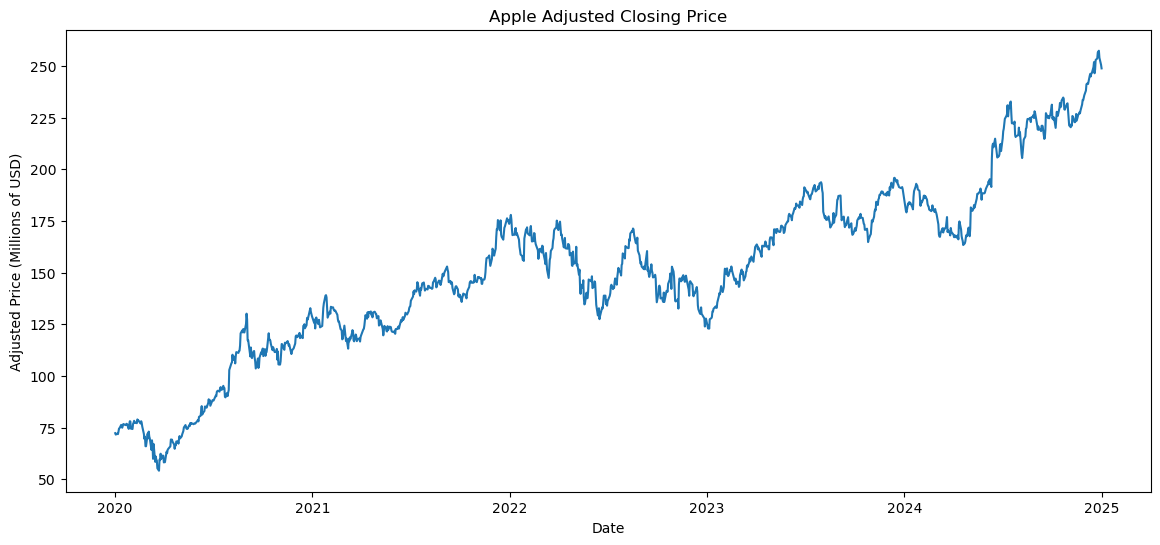

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(apple['Adj Close'])
plt.title('Apple Adjusted Closing Price')
plt.xlabel('Date')
plt.ylabel('Adjusted Price (Millions of USD)')
plt.show()

**Remark:** The adjusted closing price reflects corporate actions such as stock splits and dividends, providing a more accurate representation of the stock's historical value. Throuought this project we work with adjasted closing price.

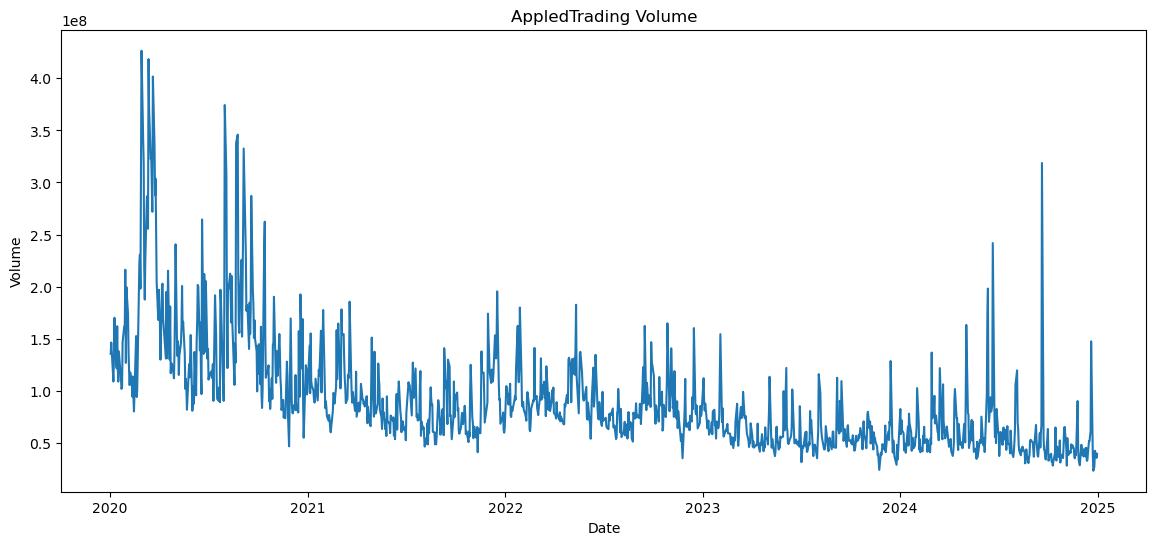

In [10]:
plt.figure(figsize=(14, 6))

plt.plot(apple['Volume'])

plt.title('AppledTrading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.show()

**Remark:** Trading volume fluctuates considerably over time, with significant spikes during periods of heightened market activity.

## 6. Moving Averages Analysis

Moving averages are commonly used in financial analysis to smooth short-term fluctuations and identify underlying trends in stock prices.

In [11]:
apple['MA30'] = apple['Adj Close'].rolling(window=30).mean()
apple['MA100'] = apple['Adj Close'].rolling(window=100).mean()

The 30-day moving average captures shorter-term market movements, while the 100-day moving average reflects longer-term trends.

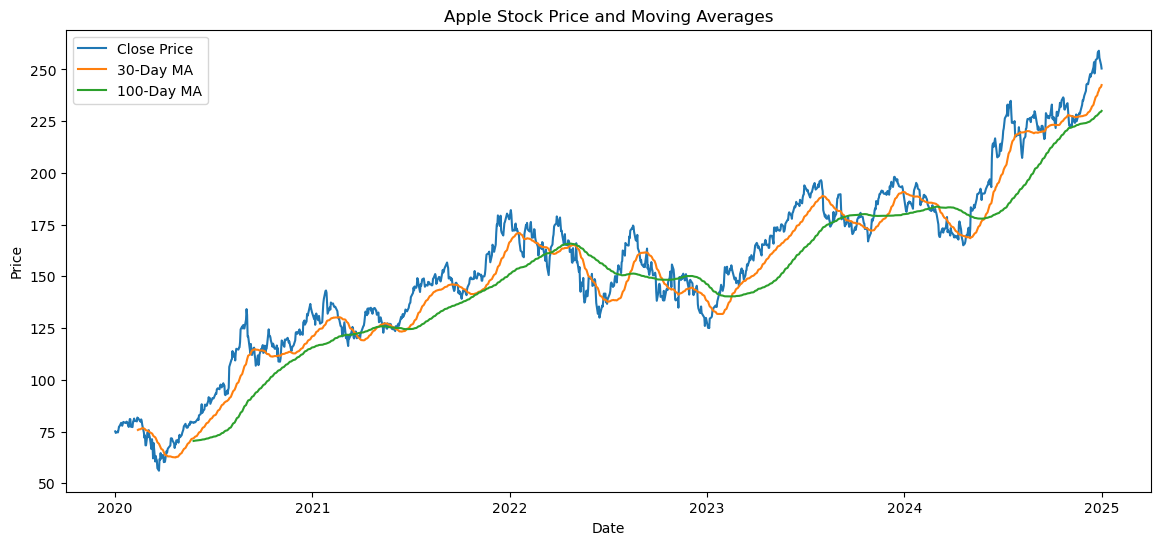

In [12]:
plt.figure(figsize=(14,6))

plt.plot(apple['Close'], label='Close Price')
plt.plot(apple['MA30'], label='30-Day MA')
plt.plot(apple['MA100'], label='100-Day MA')

plt.title('Apple Stock Price and Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.show()

**Remark:** Intersections between the short-term and long-term moving averages may indicate potential changes in market momentum.

In particular, when the 30-day moving average crosses above the 100-day moving average, it may suggest a strengthening upward trend, while the opposite case may indicate weakening momentum.

## 7. Log Returns Analysis

In financial analysis, returns are often more informative than raw stock prices, since they measure the relative change in value over time.

There are two common types of returns: simple returns and logarithmic returns, given by the following formulas respectively:

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

$$
R_t = \log\left(\frac{P_t}{P_{t-1}}\right),
$$

where $P_t$ denotes the adjusted closing price on day $t$.

It is clear that simple returns express the percentage change in price from one trading day to the next, while logarithmic returns measure the same change on a logarithmic scale.

In this section, we use logarithmic returns because they are additive over time, which makes them more convenient for mathematical calculations and statistical modeling.

Moreover, logarithmic returns are widely used in stochastic financial models such as Geometric Brownian Motion.

In [13]:
apple['Log Returns'] = np.log(apple['Adj Close'] / apple['Adj Close'].shift(1))

apple[['Adj Close', 'Log Returns']].head()

Price,Adj Close,Log Returns
Date,,
2020-01-02,72.333885,NaN
2020-01-03,71.630630,-0.009770
2020-01-06,72.201424,0.007937
2020-01-07,71.861847,-0.004714
2020-01-08,73.017838,0.015958


We now visualize the log returns in order to examine their variability and identify periods of unusually large market movements.

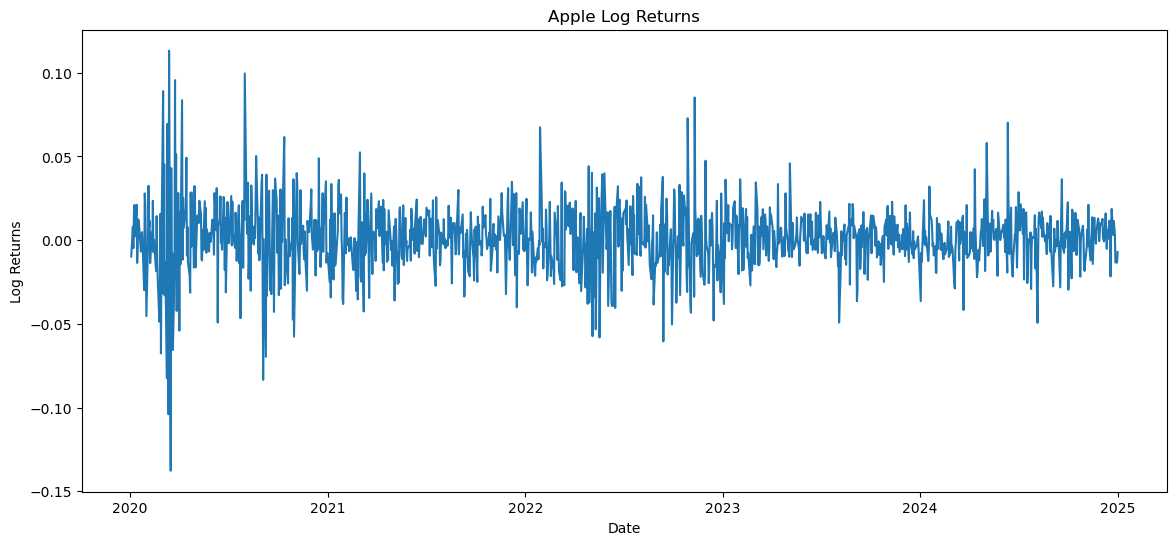

In [14]:
plt.figure(figsize=(14,6))

plt.plot(apple['Log Returns'])

plt.title('Apple Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Returns')

plt.show()

The log returns fluctuate around zero and exhibit periods of increased volatility, characterized by larger positive and negative movements.

We next examine some descriptive statistics of the log returns.

In [15]:
apple['Log Returns'].describe()

count    1257.000000
mean        0.000983
std         0.019940
min        -0.137708
25%        -0.008460
50%         0.001186
75%         0.011917
max         0.113157
Name: Log Returns, dtype: float64

The descriptive statistics provide insight into the average daily performance of the stock, as well as the magnitude of its fluctuations and extreme market movements.

We now examine the distribution of the logarithmic returns in order to better understand their statistical behavior.

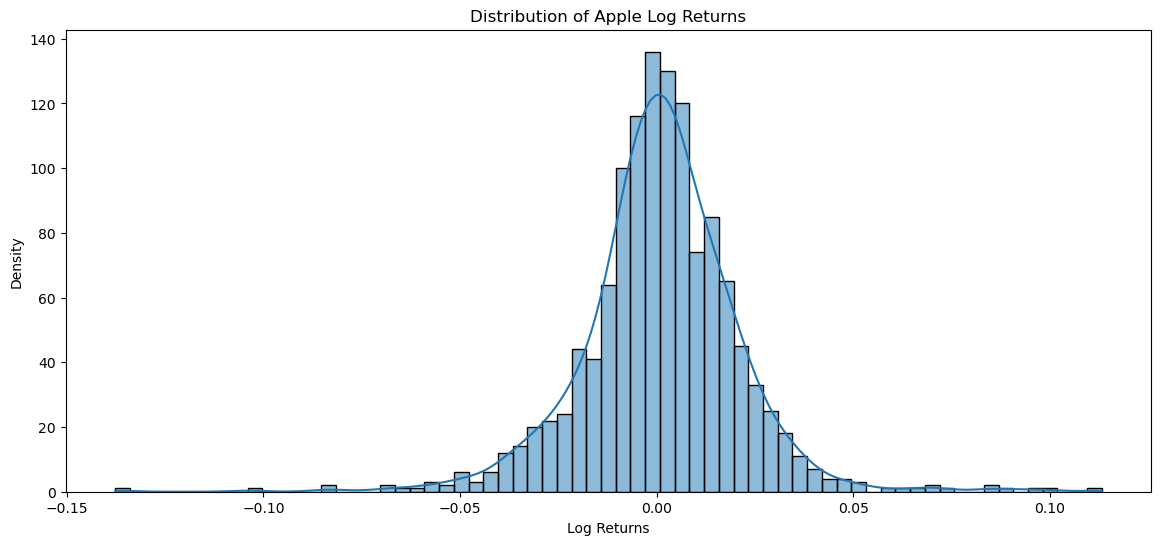

In [16]:
plt.figure(figsize=(14,6))

sns.histplot(apple['Log Returns'], kde=True)
plt.title('Distribution of Apple Log Returns')
plt.xlabel('Log Returns')
plt.ylabel('Density')

plt.show()

The distribution of logarithmic returns appears to be centered around zero, with most observations concentrated near small daily changes.

However, the presence of extreme positive and negative returns suggests heavier tails and periods of increased market volatility.

We further examine the statistical properties of the logarithmic returns by calculating their skewness and kurtosis.

In [17]:
skewness = apple['Log Returns'].skew()

kurtosis = apple['Log Returns'].kurtosis()

print("Skewness:", skewness)

print("Kurtosis:", kurtosis)

Skewness: -0.11245705609003405
Kurtosis: 5.383354957571116


Skewness measures the asymmetry of the return distribution, while kurtosis measures the heaviness of its tails.

In financial data, high kurtosis is often associated with the presence of extreme market movements and deviations from the normal distribution.

To further investigate the normality of the logarithmic returns, we construct a Q-Q plot comparing the empirical distribution of the data with a theoretical normal distribution.

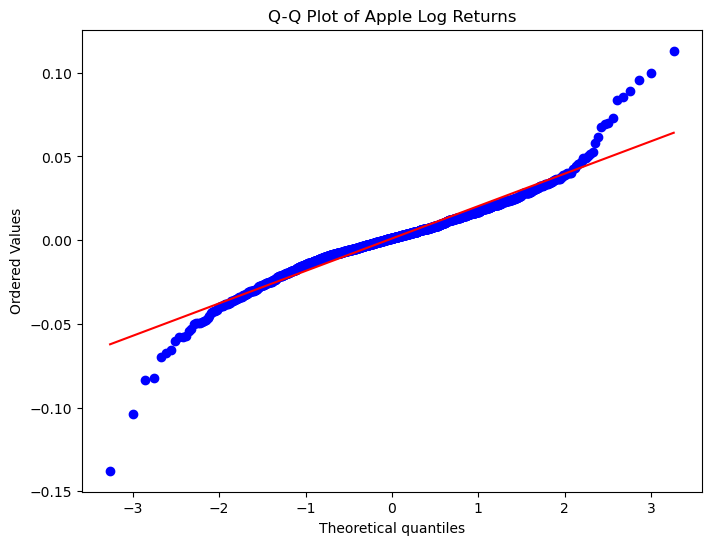

In [18]:
plt.figure(figsize=(8,6))

stats.probplot(
    apple['Log Returns'].dropna(),
    dist='norm',
    plot=plt
)

plt.title('Q-Q Plot of Apple Log Returns')

plt.show()

The Q-Q plot suggests that the logarithmic returns deviate from normality, particularly in the tails of the distribution.

This behavior is common in financial time series and reflects the presence of extreme market events and volatility clustering.

Overall, the analysis of logarithmic returns reveals important statistical characteristics of financial time series, including volatility clustering, heavy tails, and deviations from normality.

## 8. Mean Return & Volatility Analysis

Mean return and volatility are two of the most important statistical quantities in financial analysis.

The mean return provides information about the average performance of the asset, while volatility measures the variability and uncertainty of returns over time.

In this section, we examine the annualized mean logarithmic return and volatility of Apple's stock.

The annualized log return represents the stock's average yearly performance based on its daily logarithmic returns and is given by the following formula:
$$\mu_{annual} = \mu_{daily}252,$$

where $252$ represents the approximate number of tradinig days in a year.

In [19]:
annual_mean = apple['Log Returns'].mean() * 252
print(annual_mean)

0.2476853478195458


Volatility is commonly measured using the standard deviation of log returns:
$$\sigma = \sqrt{\frac{1}{n-1}\sum\limits_{i=1}^{n}(R_i-\bar{R})^2},$$

where $R_i$ and $\bar{R}$ denote the log returns and their mean, respectively.
Once again, we annualize volatility in order to express risk on a yearly basis:
$$\sigma_{annual} = \sigma_{daily}\sqrt{252}.$$



In [20]:
apple_volatility = apple['Log Returns'].std() * np.sqrt(252)
print(apple_volatility)

0.31654035105042166


We now examine how volatility evolves over time by calculating the rolling standard deviation of logarithmic returns.

In [21]:
apple['Rolling Volatility'] = (apple['Log Returns'].rolling(window=30).std())

Next, we visualize the rolling volatility in order to identify periods of increased market uncertainty and instability.

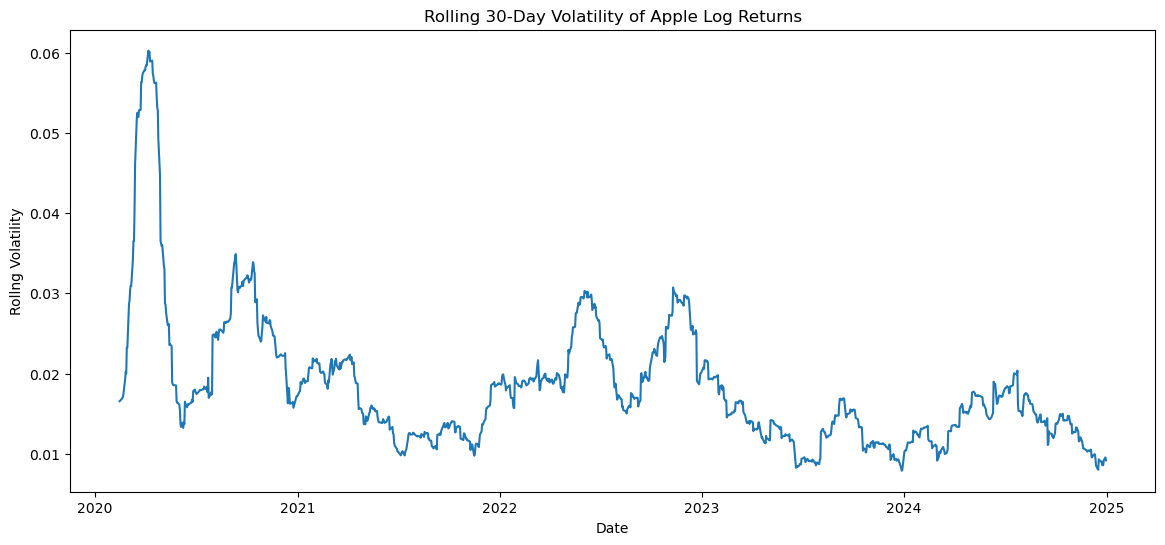

In [22]:
plt.figure(figsize=(14,6))

plt.plot(apple['Rolling Volatility'])
plt.title('Rolling 30-Day Volatility of Apple Log Returns')
plt.xlabel('Date')
plt.ylabel('Rollng Volatility')

plt.show()

**Remark:** The rolling volatility varies significantly over time and exhibits periods of elevated market uncertainty. Clusters of high volatility are visible during periods of strong market movements, indicating that volatility tends to persist over time.

Overall, the volatility analysis highlights the dynamic nature of financial markets and the presence of time-varying uncertainty in stock returns.

## 9. Conclusions

In this project, we analyzed Apple's stock behavior using statistical and quantitative finance techniques.

By examining logarithmic returns, moving averages, return distributions, and rolling volatility, we identified several important characteristics of financial time series, including volatility clustering, heavy-tailed behavior, and deviations from normality.

Overall, the analysis demonstrates how statistical tools and data visualization techniques can provide valuable insights into stock market dynamics and financial risk.